## Signal mit Rauschen (AWGN)

Vorhergehendes Notebook: [Spektralanalyse](03_Spektralanalyse.ipynb)  
Nächstes Notebook: [Details zur FFT](05_FFT_details.ipynb)

### Erzeugung von Rauschen mit np.random

Für **additives weißes gaußsches Rauschen (AWGN)** erzeugen wir Zufallszahlen mit **NumPy**: `np.random.normal(mittelwert, standardabweichung, size)` liefert normalverteilte (gaußverteilte) Zufallszahlen. Für mittelwertfreies Rauschen verwenden wir den Mittelwert 0.

Wichtige Parameter:

- **Seed (np.random.seed)** – Setzt den Zufallsgenerator auf einen festen Startwert. Bei gleichem Seed entstehen bei jedem Lauf **dieselben** Zufallszahlen (reproduzierbar). Ohne festes Seed ist jede Realisierung unterschiedlich.
- **Standardabweichung (sigma)** – Legt die „Stärke“ des Rauschens fest: Je größer sigma, desto größer die typischen Abweichungen vom Nutzsignal. Die Rauschleistung ist proportional zu sigma².

Beispiel: `np.random.seed(42)`; `rauschen = np.random.normal(0, sigma, N)` erzeugt *N* mittelwertfreie Gauß-Zufallszahlen mit Standardabweichung *sigma*. Das Nutzsignal und das Rauschsignal werden addiert (daher „additiv“).

### Teil 1: Reelles Cosinus-Signal $A\,\cos(\omega t + \phi)$ + AWGN

Parameter: Amplitude *A*, Frequenz *f* (Hz), Phase *φ* in Grad; Abtastrate 1 kHz, 1024 Punkte. Rauschen: Seed und Standardabweichung *sigma*.

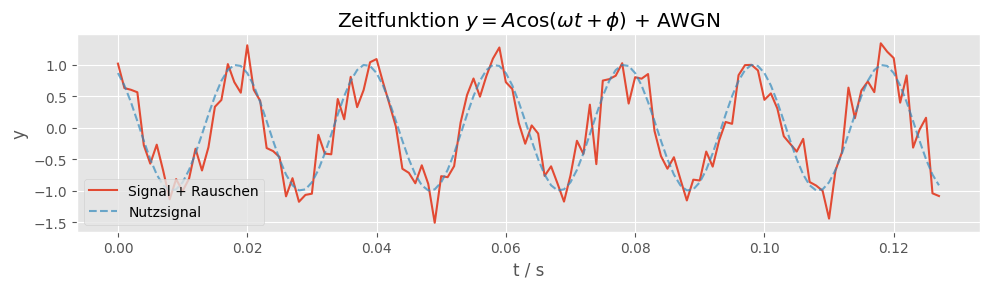

In [1]:
import numpy as np
from matplotlib import pyplot as plt
plt.style.use('ggplot')

fs = 1000.0   # Abtastrate in Hz
N = 128      # Anzahl Punkte
A = 1.0       # Amplitude
f = 50.0      # Frequenz in Hz
phi_deg = 30  # Phase in Grad
sigma = 0.3   # Standardabweichung des AWGN
np.random.seed(42)  # Reproduzierbarkeit

phi_rad = np.deg2rad(phi_deg)
t = np.arange(N) / fs
omega = 2 * np.pi * f
y_signal = A * np.cos(omega * t + phi_rad)
rauschen = np.random.normal(0, sigma, N)
y = y_signal + rauschen

plt.figure(figsize=(10, 3))
plt.plot(t, y, label='Signal + Rauschen')
plt.plot(t, y_signal, '--', alpha=0.7, label='Nutzsignal')
plt.xlabel('t / s')
plt.ylabel('y')
plt.title(r'Zeitfunktion $y = A \cos(\omega t + \phi)$ + AWGN')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

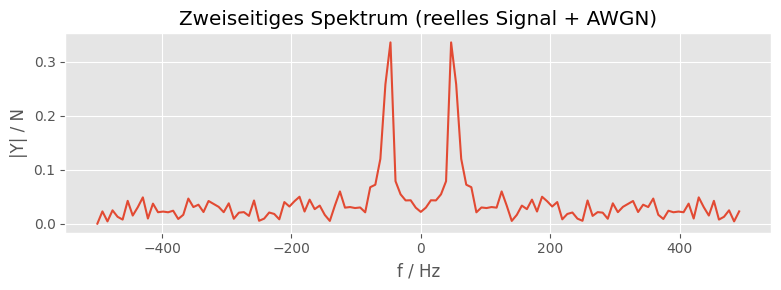

In [2]:
# Zweiseitiges Spektrum (wie in 03_Spektralanalyse)
Y = np.fft.fft(y)
freq = np.fft.fftfreq(N, d=1/fs)
freq_shifted = np.fft.fftshift(freq)
Y_shifted = np.fft.fftshift(Y)
magnitude = np.abs(Y_shifted) / N

plt.figure(figsize=(8, 3))
plt.plot(freq_shifted, magnitude)
plt.xlabel('f / Hz')
plt.ylabel('|Y| / N')
plt.title('Zweiseitiges Spektrum (reelles Signal + AWGN)')
plt.grid(True)
plt.tight_layout()
plt.show()

### Teil 2: Komplexes Signal (Cosinus + j·Sinus) + AWGN

Wir bilden das komplexe Signal $z(t) = A\,e^{j(\omega t + \phi)}$ und addieren Rauschen. **Hinweis:** Für Real- und Imaginärteil werden **getrennte**, **unkorreliert** erzeugte Rauschsignale verwendet: $z_{\text{gestört}} = z + (n_1 + j\,n_2)$ mit zwei unabhängigen Realisierungen $n_1$, $n_2$ von AWGN. So bleibt die statistische Unabhängigkeit von I und Q erhalten.

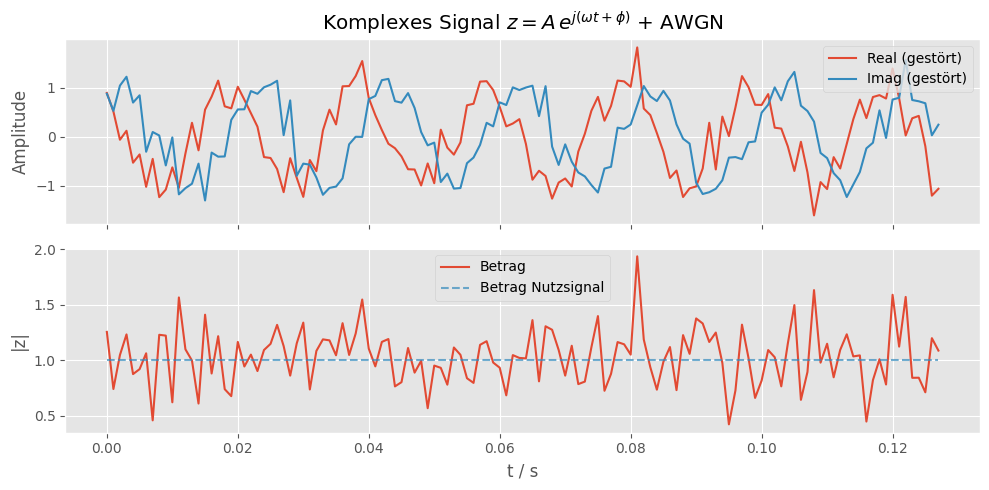

In [3]:
# Komplexes Signal + AWGN (unabhängiges Rauschen auf Real- und Imaginärteil)
z_signal = A * np.exp(1j * (omega * t + phi_rad))
rauschen_real = np.random.normal(0, sigma, N)   # eigenes Rauschen für Realteil
rauschen_imag = np.random.normal(0, sigma, N)   # unkorreliertes Rauschen für Imaginärteil
z = z_signal + (rauschen_real + 1j * rauschen_imag)

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(t, np.real(z), label='Real (gestört)')
axes[0].plot(t, np.imag(z), label='Imag (gestört)')
axes[0].set_ylabel('Amplitude')
axes[0].set_title(r'Komplexes Signal $z = A\,e^{j(\omega t + \phi)}$ + AWGN')
axes[0].legend()
axes[0].grid(True)
axes[1].plot(t, np.abs(z), label='Betrag')
axes[1].plot(t, np.abs(z_signal), '--', alpha=0.7, label='Betrag Nutzsignal')
axes[1].set_xlabel('t / s')
axes[1].set_ylabel('|z|')
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.show()

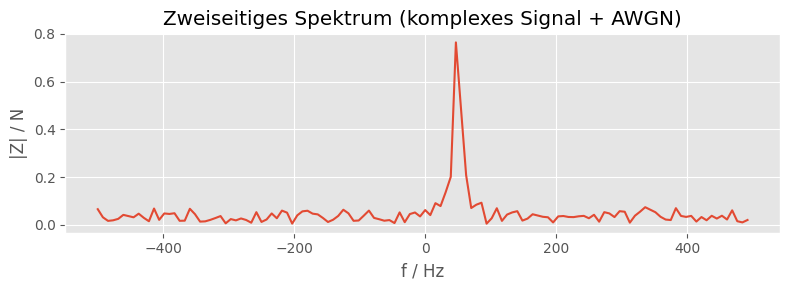

In [4]:
# Zweiseitiges Spektrum des komplexen Signals mit Rauschen
Z = np.fft.fft(z)
freq_z = np.fft.fftfreq(N, d=1/fs)
freq_z_shifted = np.fft.fftshift(freq_z)
Z_shifted = np.fft.fftshift(Z)
magnitude_z = np.abs(Z_shifted) / N

plt.figure(figsize=(8, 3))
plt.plot(freq_z_shifted, magnitude_z)
plt.xlabel('f / Hz')
plt.ylabel('|Z| / N')
plt.title('Zweiseitiges Spektrum (komplexes Signal + AWGN)')
plt.grid(True)
plt.tight_layout()
plt.show()

---

### Schlussfolgerung – Aufgaben für Studierende

1. **Frage:** Mit welcher Analyse (Oszilloskop, Spektralanalysator) kann man das Signal vom Rauschen getrennt messen? Begründe die Antwort.

2. **Experiment:** Verzehnfache (!) den Wert für die Standardabweichung des Rauschsignals (*sigma*) und führe den Code wiederholt aus. Erkläre deine Beobachtungen von Zeitfunktion und Spektren.

*Trage deine Antworten in die folgende Markdown-Zelle ein.*

*Hier deine Antworten eintragen: …*

Vorhergehendes Notebook: [Spektralanalyse](03_Spektralanalyse.ipynb)  
Nächstes Notebook: [Details zur FFT](05_FFT_details.ipynb)